In [43]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import pandas as pd
import numpy as np


In [44]:
years = [2018, 2019, 2020, 2021, 2022]
sales = [100, 150, 200, 180, 220]
fig = go.Figure(data= go.Scatter(x = years, y= sales))
print(fig)

Figure({
    'data': [{'type': 'scatter', 'x': [2018, 2019, 2020, 2021, 2022], 'y': [100, 150, 200, 180, 220]}],
    'layout': {'template': '...'}
})


In [45]:
import pandas as pd  
import numpy as np 
import warnings 
warnings.filterwarnings('ignore')


In [46]:
path = 'Titanic.csv'

In [47]:
df = pd.read_csv(path)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [48]:
# path = 'train.csv'

# df  = pd.read_csv(path)
# df.head()
df.drop(['PassengerId','Name','Ticket'], axis=1,inplace=True)

In [7]:
def chk_types(df):
    dtypes =df.dtypes
    n_unique = df.nunique()
    return pd.DataFrame({"Dtypes":dtypes,"Num_uniques":n_unique}).T

In [8]:
# from process import chk_types
# chk_types(df)

In [49]:
cols = ['Survived','Pclass','Parch','Sex','Embarked','SibSp']


df[cols] = df[cols].astype('category')
chk_types(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,category,category,category,float64,category,category,float64,str,category
Num_uniques,2,3,2,88,7,7,248,147,3


In [41]:
null = df.isnull().sum()
ratio = round( (null /df.shape[0])*100 ,2).astype(str) +"%"
pd.DataFrame({"Null_sum": null, "Ratio %": ratio}).T

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
Null_sum,0,0,0,0,0,177,0,0,0,0,0
Ratio %,0.0%,0.0%,0.0%,0.0%,0.0%,19.91%,0.0%,0.0%,0.0%,0.0%,0.0%


In [40]:
df1 = df.dropna(subset=['Embarked'], inplace= True)
df2 = df.drop("Cabin", axis=1, inplace= True)


In [12]:
median =  df['Age'].median()
df['Age'].fillna(median, inplace= True)

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: Age, Length: 889, dtype: float64

In [13]:
null = df.isnull().sum()
ratio = round( (null /df.shape[0])*100 ,2).astype(str) +"%"
pd.DataFrame({"Null_sum": null, "Ratio %": ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Null_sum,0,0,0,177,0,0,0,0
Ratio %,0.0%,0.0%,0.0%,19.91%,0.0%,0.0%,0.0%,0.0%


In [14]:
num_cols = df.select_dtypes('number').columns
num_cols

Index(['Age', 'Fare'], dtype='str')

In [32]:
cat_cols = df.select_dtypes('category').columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

In [16]:
px.colors.qualitative.Pastel

['rgb(102, 197, 204)',
 'rgb(246, 207, 113)',
 'rgb(248, 156, 116)',
 'rgb(220, 176, 242)',
 'rgb(135, 197, 95)',
 'rgb(158, 185, 243)',
 'rgb(254, 136, 177)',
 'rgb(201, 219, 116)',
 'rgb(139, 224, 164)',
 'rgb(180, 151, 231)',
 'rgb(179, 179, 179)']

In [17]:

fig = px.pie(df,
             names="Survived",
             title = '<b>Survived Distribution</b>',
             color_discrete_sequence=px.colors.qualitative.Pastel,
             #color_discrete_map={'Survived': 'blue', 'Not Survived': 'red'},
             hole=0.4
             )
fig.update_layout(annotations=[dict(text='Survived', x=0.5, y=0.5, font_size=20, showarrow=True)])
fig.show()

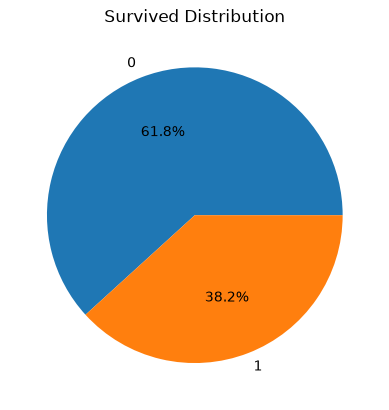

In [18]:
import matplotlib.pyplot as plt
counts = df['Survived'].value_counts()

plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%'
)
plt.title('Survived Distribution')
plt.show()

In [19]:

fig = px.pie(df,
             names='Survived',
             title = '<b>Survived Distribution</b>',
             color_discrete_sequence=px.colors.qualitative.Pastel,
             hole=0.7)
fig.update_layout(annotations = [dict(text = 'Survived', font_size = 20, x = 0.5, y = 0.5, showarrow = False)])

In [20]:
px.histogram(df, 
             x = 'Survived',
             color='Sex',
             title='<b> Survived based on Gender</b>', 
             barmode='group')
fig.update_layout(width=700, height = 500, bargap = 0.2)
fig.show()

In [21]:
fig = px.histogram(df,x='Survived',color='Sex',title='<b> Survived base on Gender', barmode='group')#stacked
fig.update_layout(width= 400, height = 300, bargap = 0.2)
fig.show()

In [22]:
fig = px.box(df, y ="Age", points='all', title="Titanic Age box plot with outliers")
fig.show()
fig_1 = px.box(df, y ="Fare", points='all', title="Titanic Age box plot with outliers")
fig_1.show()

In [23]:
col = 'Age'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
normal = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]
fig = go.Figure()
fig.add_trace(go.Scatter(y= normal[col], mode = 'markers', name='Normal'))
fig.add_trace(go.Scatter(y = outliers[col], mode = 'markers',
                         marker = dict(color= 'red', size = 10)))


In [24]:
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='str')

In [25]:
import plotly.express as px
import plotly.subplots as sp
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create subplot layout: 2 rows × 3 columns
fig = sp.make_subplots(rows=2, cols=3, subplot_titles=cat_cols,
                       specs=[[{'type':'domain'}]*3, [{'type':'domain'}]*3])

for i, col in enumerate(cat_cols):
    row = i // 3 + 1
    col_pos = i % 3 + 1
    
    unique = df[col].value_counts()
    categories = unique.index
    count = unique.values
    
    fig.add_trace(
        go.Pie(labels = categories, values = count, name= col, hole = 0.4, textinfo = "percent + label"),
        row =row, col = col_pos
    )
fig.update_layout(height = 600, width = 1000)
fig.show()

In [26]:
fig = make_subplots(rows=2, cols=3, subplot_titles=cat_cols)
for i, col in enumerate(cat_cols):
    fig.add_trace(go.Histogram(x=df[col]), row=i//3 + 1, col=i%3 + 1)
fig.show()    

In [27]:
fig = make_subplots(rows=2, cols=3, subplot_titles=cat_cols)
for i, col in enumerate(cat_cols):
    fig.add_trace(go.Histogram(x=df[col]), row=1//3 + 1, col=1% 3 + 1)
fig.show()    

## starting of machine learning


In [90]:
x = df.drop(['Survived', 'Cabin'], axis=1)
# x= df.drop(['Cabin'], axis=1)
y = df['Survived']
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: category
Categories (2, int64): [0, 1]

In [86]:
x = df.iloc[:, 1: ]
y = df.iloc[:, [0]]

In [83]:
# x= df.drop(['Cabin'], axis=1)
# x= df.drop(['survived'], axis=1)

In [91]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


In [97]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
scaler = MinMaxScaler()
scaler.fit(x[num_cols])
x[num_cols] = scaler.transform(x[num_cols])
 # scaler.fit_transform # used to scale the numerical columns in the dataset. The MinMaxScaler scales the features to a given range, typically between 0 and 1. This is useful for algorithms that are sensitive to the scale of input data, such as gradient descent-based methods, it inherent from the fact that features with larger ranges can dominate the learning process, leading to suboptimal model performance. By scaling the features, we ensure that each feature contributes equally to the model's learning process, improving convergence and overall performance.

In [99]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,0.271174,1,0,0.014151,S
1,1,female,0.472229,1,0,0.139136,C
2,3,female,0.321438,0,0,0.015469,S
3,1,female,0.434531,1,0,0.103644,S
4,3,male,0.434531,0,0,0.015713,S


In [101]:
from category_encoders import OneHotEncoder
str_cols = x.select_dtypes('category').columns
encoder = OneHotEncoder(cols=str_cols, drop_invariant=True, use_cat_names=True)
x = encoder.fit_transform(x)

In [102]:
x.head()

,Pclass_3.0,Pclass_1.0,Pclass_2.0,Sex_male,Sex_female,Age,SibSp_1.0,SibSp_0.0,SibSp_3.0,SibSp_4.0,...,Parch_2.0,Parch_5.0,Parch_3.0,Parch_4.0,Parch_6.0,Fare,Embarked_S,Embarked_C,Embarked_Q,Embarked_nan
0,1,0,0,1,0,0.271174,1,0,0,0,...,0,0,0,0,0,0.014151,1,0,0,0
1,0,1,0,0,1,0.472229,1,0,0,0,...,0,0,0,0,0,0.139136,0,1,0,0
2,1,0,0,0,1,0.321438,0,1,0,0,...,0,0,0,0,0,0.015469,1,0,0,0
3,0,1,0,0,1,0.434531,1,0,0,0,...,0,0,0,0,0,0.103644,1,0,0,0
4,1,0,0,1,0,0.434531,0,1,0,0,...,0,0,0,0,0,0.015713,1,0,0,0
